# Schelling's Model of Segregation: Micro-Motives, Macro-Patterns

Thomas Schelling's 1971 paper **Dynamic Models of Segregation** showed how mild local preferences can create much stronger aggregate segregation than any individual explicitly aimed for.

The teaching model is intentionally small:

- a grid contains two kinds of agents and some empty spaces,
- each agent checks its immediate neighbors,
- an agent is satisfied if enough neighbors are similar,
- unsatisfied agents move to empty locations.

The central lesson is subtle and powerful:

> Micro-motives do not automatically equal macro-behavior.


## 1. Model and Ethics Note

Schelling's model is a minimal abstraction. It is useful because it isolates one mechanism: local preference plus movement can amplify into global clustering.

It is not a complete explanation of real-world segregation. Actual segregation is also shaped by law, violence, wealth, housing markets, discrimination, zoning, schools, lending, policy, geography, and history.

A good model tells us what a mechanism can do. It does not excuse the mechanism, and it does not replace social evidence.


## 2. The Mental Model

Each occupied cell has up to eight neighbors. A red or blue agent is **happy** when:

```text
same-color occupied neighbors / occupied neighbors >= tolerance threshold
```

In this notebook, a threshold of `0.30` means an agent is satisfied even when only 30% of its occupied neighbors are similar. That is a mild preference, not a demand for uniformity.

Empty neighboring cells do not count in the denominator. Agents with no occupied neighbors are treated as satisfied.


## 3. Build the Grid


**Imports and setup.** Load arrays, plotting, animation, and small data containers.


In [1]:
from dataclasses import dataclass
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from matplotlib.colors import ListedColormap


**Configuration.** Keep the model knobs in one named object.


In [2]:
EMPTY = 0
RED = 1
BLUE = 2


@dataclass(frozen=True)
class SchellingConfig:
    size: int = 36
    red_fraction: float = 0.45
    blue_fraction: float = 0.45
    threshold: float = 0.30
    max_rounds: int = 80
    seed: int = 12


**Initial board.** Randomly place red agents, blue agents, and empty cells while preserving counts.


In [3]:
def initialize_board(config: SchellingConfig) -> np.ndarray:
    rng = np.random.default_rng(config.seed)
    total = config.size * config.size
    red_count = round(total * config.red_fraction)
    blue_count = round(total * config.blue_fraction)
    empty_count = total - red_count - blue_count
    if empty_count <= 0:
        raise ValueError("The model needs at least one empty cell for movement.")

    cells = np.array([RED] * red_count + [BLUE] * blue_count + [EMPTY] * empty_count)
    rng.shuffle(cells)
    return cells.reshape(config.size, config.size)


config = SchellingConfig()
board = initialize_board(config)
np.unique(board, return_counts=True)


(array([0, 1, 2]), array([130, 583, 583]))

## 4. Happiness Rule

The model's local rule is a neighbor count. The board wraps at the edges here, so every cell has the same eight-neighbor geometry. That avoids edge artifacts and keeps the rule simple.


**Neighbor coordinates.** Look around a cell using the eight Moore-neighborhood offsets.


In [4]:
NEIGHBOR_OFFSETS = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def neighbor_values(board: np.ndarray, row: int, col: int) -> list[int]:
    size = board.shape[0]
    return [
        int(board[(row + dr) % size, (col + dc) % size])
        for dr, dc in NEIGHBOR_OFFSETS
    ]


**Happiness function.** Return both the Boolean decision and the observed same-neighbor ratio.


In [5]:
def agent_satisfaction(board: np.ndarray, row: int, col: int, threshold: float) -> tuple[bool, float]:
    agent = int(board[row, col])
    if agent == EMPTY:
        return True, np.nan

    occupied_neighbors = [value for value in neighbor_values(board, row, col) if value != EMPTY]
    if not occupied_neighbors:
        return True, 1.0

    same = sum(value == agent for value in occupied_neighbors)
    ratio = same / len(occupied_neighbors)
    return ratio >= threshold, ratio


agent_satisfaction(board, 0, 0, config.threshold)


(False, 0.14285714285714285)

**Locate unhappy agents.** Scan the board and collect agents below the threshold.


In [6]:
def unhappy_agents(board: np.ndarray, threshold: float) -> list[tuple[int, int]]:
    unhappy = []
    for row in range(board.shape[0]):
        for col in range(board.shape[1]):
            happy, _ = agent_satisfaction(board, row, col, threshold)
            if not happy:
                unhappy.append((row, col))
    return unhappy


len(unhappy_agents(board, config.threshold))


207

## 5. Movement Rule

Unsatisfied agents move to empty cells. This is not a market, not a full housing model, and not a claim about real individual behavior. It is a small rule designed to reveal an amplification mechanism.

Important invariant:

> A move changes positions, but it preserves the number of red agents, blue agents, and empty cells.


**One round.** Shuffle unhappy agents and empty cells, then relocate as many unhappy agents as possible.


In [7]:
def empty_cells(board: np.ndarray) -> list[tuple[int, int]]:
    rows, cols = np.where(board == EMPTY)
    return list(zip(rows.tolist(), cols.tolist()))


def step_schelling(board: np.ndarray, threshold: float, rng: np.random.Generator) -> tuple[np.ndarray, int]:
    next_board = board.copy()
    unhappy = unhappy_agents(board, threshold)
    vacancies = empty_cells(board)
    rng.shuffle(unhappy)
    rng.shuffle(vacancies)

    moved = 0
    while unhappy and vacancies:
        source = unhappy.pop()
        target = vacancies.pop()
        if next_board[source] == EMPTY:
            continue
        next_board[target] = next_board[source]
        next_board[source] = EMPTY
        vacancies.append(source)
        moved += 1

    return next_board, moved


next_board, moved = step_schelling(board, config.threshold, np.random.default_rng(0))
moved


207

## 6. Measuring Segregation

Visual patterns matter, but we also want numerical handles:

- **happy fraction**: what proportion of agents are satisfied?
- **mean same-neighbor ratio**: how similar each agent's local neighborhood is on average.
- **largest cluster**: size of the largest connected same-color region.


**Cluster helper.** Flood-fill connected agents of the same color.


In [8]:
def largest_same_color_cluster(board: np.ndarray) -> int:
    visited = np.zeros_like(board, dtype=bool)
    best = 0
    size = board.shape[0]

    for start_row in range(size):
        for start_col in range(size):
            color = int(board[start_row, start_col])
            if color == EMPTY or visited[start_row, start_col]:
                continue

            queue = deque([(start_row, start_col)])
            visited[start_row, start_col] = True
            cluster_size = 0

            while queue:
                row, col = queue.popleft()
                cluster_size += 1
                for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nr = (row + dr) % size
                    nc = (col + dc) % size
                    if not visited[nr, nc] and int(board[nr, nc]) == color:
                        visited[nr, nc] = True
                        queue.append((nr, nc))

            best = max(best, cluster_size)

    return best


**Metric function.** Summarize one board state.


In [9]:
def segregation_metrics(board: np.ndarray, threshold: float) -> dict[str, float]:
    ratios = []
    happy_count = 0
    agent_count = 0

    for row in range(board.shape[0]):
        for col in range(board.shape[1]):
            if board[row, col] == EMPTY:
                continue
            happy, ratio = agent_satisfaction(board, row, col, threshold)
            agent_count += 1
            happy_count += int(happy)
            ratios.append(ratio)

    return {
        "happy_fraction": happy_count / agent_count,
        "mean_same_neighbor_ratio": float(np.nanmean(ratios)),
        "largest_cluster": largest_same_color_cluster(board),
        "agent_count": agent_count,
    }


segregation_metrics(board, config.threshold)


{'happy_fraction': 0.8224699828473413,
 'mean_same_neighbor_ratio': 0.49081924364943225,
 'largest_cluster': 52,
 'agent_count': 1166}

**Draw a board.** Red, blue, and empty cells are shown directly.


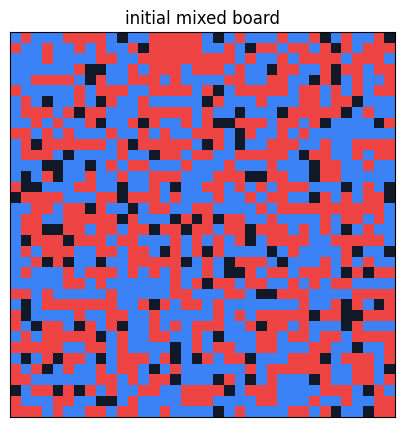

In [10]:
SCHELLING_CMAP = ListedColormap(["#111827", "#ef4444", "#3b82f6"])


def draw_board(board: np.ndarray, threshold: float, ax=None, title: str | None = None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    ax.imshow(board, cmap=SCHELLING_CMAP, vmin=0, vmax=2, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    if title is None:
        metrics = segregation_metrics(board, threshold)
        title = (
            f'happy={metrics["happy_fraction"]:.2f}, '
            f'same={metrics["mean_same_neighbor_ratio"]:.2f}'
        )
    ax.set_title(title)
    return ax


draw_board(board, config.threshold, title="initial mixed board")
plt.show()


## 7. Run the Simulation

Each round:

1. find unsatisfied agents,
2. move them to empty cells,
3. measure the new board,
4. stop if nobody moves.


**Simulation runner.** Capture a replayable history of boards and metrics.


In [11]:
def run_schelling(config: SchellingConfig, capture_every: int = 1) -> list[dict]:
    rng = np.random.default_rng(config.seed + 1000)
    board = initialize_board(config)
    history = []

    for round_number in range(config.max_rounds + 1):
        metrics = segregation_metrics(board, config.threshold)
        if round_number % capture_every == 0:
            history.append({
                "round": round_number,
                "board": board.copy(),
                "moved": 0,
                "metrics": metrics,
            })

        board, moved = step_schelling(board, config.threshold, rng)
        if history:
            history[-1]["moved"] = moved
        if moved == 0:
            break

    return history


history = run_schelling(config, capture_every=2)
len(history), history[-1]["round"], history[-1]["metrics"]


(11,
 20,
 {'happy_fraction': 1.0,
  'mean_same_neighbor_ratio': 0.7602170628114024,
  'largest_cluster': 448,
  'agent_count': 1166})

**Before and after.** Compare the mixed start against the final stable or near-stable state.


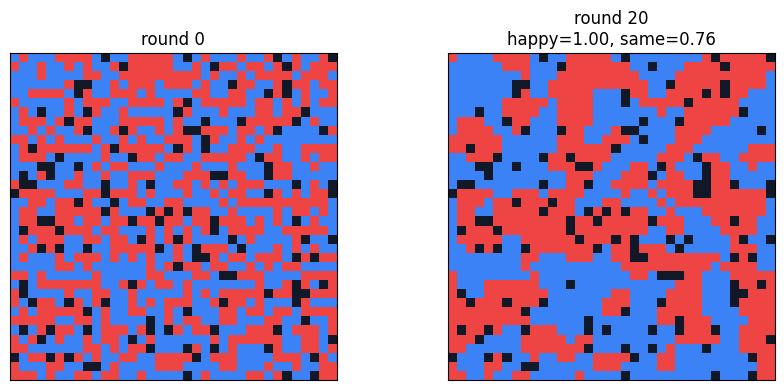

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
draw_board(history[0]["board"], config.threshold, ax=axes[0], title="round 0")
final = history[-1]
final_title = (
    f'round {final["round"]}\n'
    f'happy={final["metrics"]["happy_fraction"]:.2f}, '
    f'same={final["metrics"]["mean_same_neighbor_ratio"]:.2f}'
)
draw_board(final["board"], config.threshold, ax=axes[1], title=final_title)
plt.tight_layout()
plt.show()


**Metric trace.** Plot how satisfaction and same-neighbor ratio change over time.


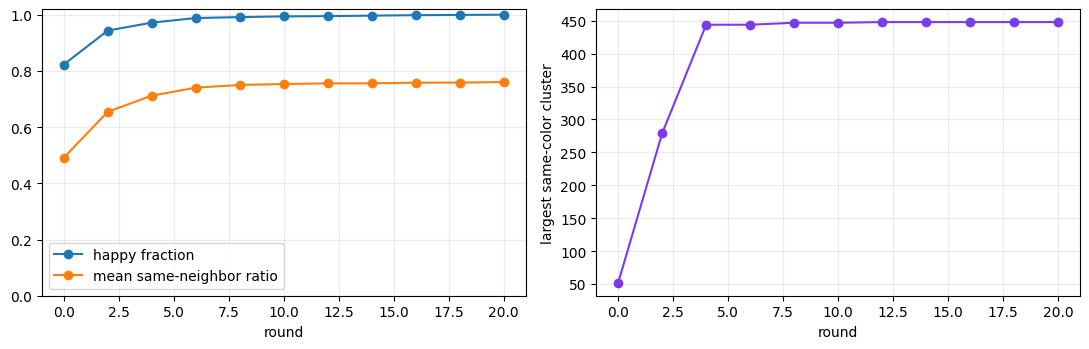

In [13]:
def plot_metrics(history: list[dict]):
    rounds = [step["round"] for step in history]
    happy = [step["metrics"]["happy_fraction"] for step in history]
    same = [step["metrics"]["mean_same_neighbor_ratio"] for step in history]
    cluster = [step["metrics"]["largest_cluster"] for step in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    axes[0].plot(rounds, happy, marker="o", label="happy fraction")
    axes[0].plot(rounds, same, marker="o", label="mean same-neighbor ratio")
    axes[0].set_ylim(0, 1.02)
    axes[0].set_xlabel("round")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(rounds, cluster, marker="o", color="#7c3aed")
    axes[1].set_xlabel("round")
    axes[1].set_ylabel("largest same-color cluster")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_metrics(history)


**Animation.** Replay the board as local moves reshape the global pattern.


In [14]:
def animate_schelling(history: list[dict], threshold: float) -> HTML:
    fig, ax = plt.subplots(figsize=(5, 5))

    def update(frame_index: int):
        ax.clear()
        step = history[frame_index]
        metrics = step["metrics"]
        draw_board(
            step["board"],
            threshold,
            ax=ax,
            title=(
                f'round {step["round"]} | moved {step["moved"]}\n'
                f'happy={metrics["happy_fraction"]:.2f}, '
                f'same={metrics["mean_same_neighbor_ratio"]:.2f}'
            ),
        )

    anim = animation.FuncAnimation(fig, update, frames=len(history), interval=180)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate_schelling(history, config.threshold)


## 8. Threshold Playground

The threshold controls how much local similarity agents require. A mild threshold can still produce strong clustering. A high threshold can produce fast clustering or persistent churn.


**Sweep thresholds.** Run the same initial density with different tolerance thresholds.


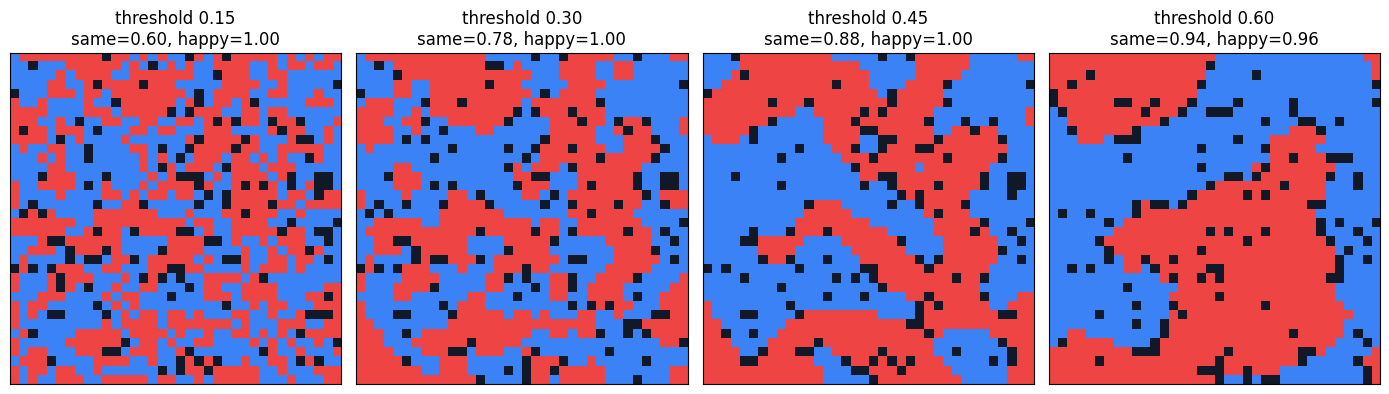

In [15]:
thresholds = [0.15, 0.30, 0.45, 0.60]
results = []

fig, axes = plt.subplots(1, len(thresholds), figsize=(14, 3.8))
for ax, threshold in zip(axes, thresholds):
    sweep_config = SchellingConfig(threshold=threshold, seed=9, max_rounds=70)
    run = run_schelling(sweep_config, capture_every=3)
    final = run[-1]
    results.append((threshold, final["metrics"]))
    title = (
        f"threshold {threshold:.2f}\n"
        f'same={final["metrics"]["mean_same_neighbor_ratio"]:.2f}, '
        f'happy={final["metrics"]["happy_fraction"]:.2f}'
    )
    draw_board(final["board"], threshold, ax=ax, title=title)

plt.tight_layout()
plt.show()


**Read the sweep.** Put the final metrics in a small table.


In [16]:
for threshold, metrics in results:
    print(
        f'threshold={threshold:.2f} | '
        f'happy={metrics["happy_fraction"]:.2f} | '
        f'same={metrics["mean_same_neighbor_ratio"]:.2f} | '
        f'largest cluster={metrics["largest_cluster"]:.0f}'
    )


threshold=0.15 | happy=1.00 | same=0.60 | largest cluster=103
threshold=0.30 | happy=1.00 | same=0.78 | largest cluster=424
threshold=0.45 | happy=1.00 | same=0.88 | largest cluster=583
threshold=0.60 | happy=0.96 | same=0.94 | largest cluster=583


## 9. Interactive Controls

If widgets are available, use sliders to adjust the threshold and vacancy rate. If not, edit the config in the fallback cell.


**Widget playground.** Re-run the model with threshold and vacancy controls.


In [17]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    threshold_slider = widgets.FloatSlider(value=0.30, min=0.0, max=0.8, step=0.05, description="threshold")
    empty_slider = widgets.FloatSlider(value=0.10, min=0.05, max=0.35, step=0.05, description="empty")

    def show_run(threshold, empty):
        red = (1 - empty) / 2
        blue = (1 - empty) / 2
        interactive_config = SchellingConfig(
            red_fraction=red,
            blue_fraction=blue,
            threshold=threshold,
            seed=14,
            max_rounds=70,
        )
        run = run_schelling(interactive_config, capture_every=4)
        draw_board(run[-1]["board"], threshold, title=f"final board, threshold={threshold:.2f}, empty={empty:.2f}")
        plt.show()

    controls = widgets.interactive_output(show_run, {"threshold": threshold_slider, "empty": empty_slider})
    display(widgets.HBox([threshold_slider, empty_slider]), controls)
except Exception:
    print("ipywidgets is not available. Edit the fallback config below.")


ipywidgets is not available. Edit the fallback config below.


**Fallback playground.** Change the threshold, empty fraction, or seed by editing this cell.


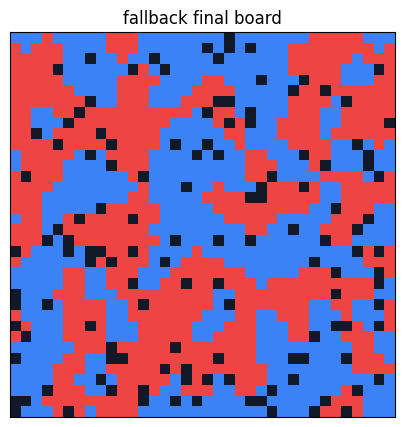

In [18]:
fallback_config = SchellingConfig(
    red_fraction=0.45,
    blue_fraction=0.45,
    threshold=0.30,
    seed=22,
    max_rounds=70,
)
fallback_history = run_schelling(fallback_config, capture_every=3)
draw_board(fallback_history[-1]["board"], fallback_config.threshold, title="fallback final board")
plt.show()


## 10. Failure Modes and Model Limits

Try to break the model:

- **No empty cells**: movement is impossible.
- **Very high threshold**: many agents can remain unsatisfied or churn.
- **Very low threshold**: the board may remain mostly mixed.
- **Different movement rule**: choosing the nearest satisfying vacancy instead of a random vacancy changes the result.
- **No institutions or history**: this model omits many forces that dominate real segregation.


**Assumption test.** Compare low, medium, and high thresholds on the same seed.


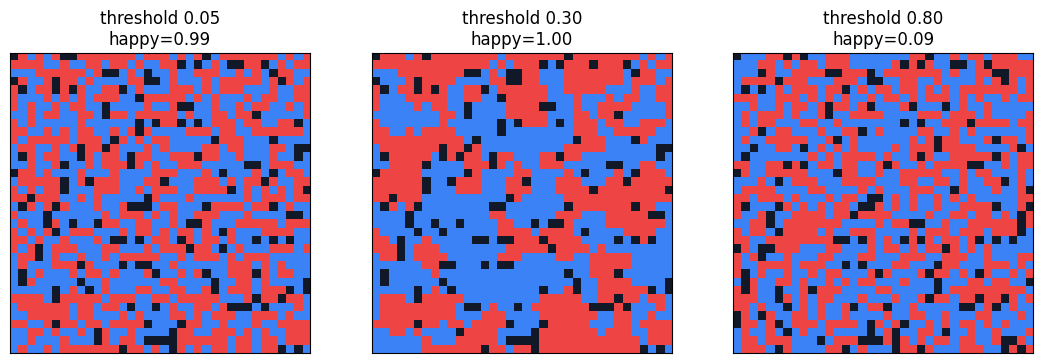

In [19]:
test_thresholds = [0.05, 0.30, 0.80]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))

for ax, threshold in zip(axes, test_thresholds):
    test_config = SchellingConfig(threshold=threshold, seed=31, max_rounds=50)
    run = run_schelling(test_config, capture_every=5)
    metrics = run[-1]["metrics"]
    draw_board(
        run[-1]["board"],
        threshold,
        ax=ax,
        title=f'threshold {threshold:.2f}\nhappy={metrics["happy_fraction"]:.2f}',
    )

plt.tight_layout()
plt.show()


## 11. Mini-Challenge

Try one:

1. Find the lowest threshold that still produces visible clustering for a fixed seed.
2. Change the vacancy rate and explain how mobility changes the result.
3. Replace wraparound boundaries with hard edges and compare the final board.
4. Change the movement rule: move only to a vacancy where the agent would be happy.


**Invariant check.** Verify that red, blue, and empty counts stay fixed across a run.


In [20]:
def counts(board: np.ndarray) -> dict[int, int]:
    values, totals = np.unique(board, return_counts=True)
    return {int(value): int(total) for value, total in zip(values, totals)}


initial_counts = counts(history[0]["board"])
final_counts = counts(history[-1]["board"])
print("initial:", initial_counts)
print("final  :", final_counts)
print("counts preserved:", initial_counts == final_counts)


initial: {0: 130, 1: 583, 2: 583}
final  : {0: 130, 1: 583, 2: 583}
counts preserved: True


## Visual Trace + Rigor Studio

**Problem frame.** Show how local satisfaction rules can produce aggregate segregation stronger than the agents' individual threshold.

**Interactive animation target.** Animate a red/blue/empty grid through movement rounds with sliders for threshold, vacancy, and random seed.

**Correctness handle.** Each move preserves the counts of red agents, blue agents, and empty cells.

**Complexity handle.** A naive round scans every grid cell and checks up to eight neighbors, so each round is `O(n^2)` for an `n by n` board. Relocation adds a scan or shuffle of empty cells.

**Failure mode to test.** Change the threshold, vacancy rate, or movement rule and show how the macro-pattern changes.

**Studio task.** Run thresholds `0.15`, `0.30`, and `0.60`; compare final mean same-neighbor ratio and explain why individual tolerance does not guarantee integrated macro-patterns.


## Sources and Further Reading

- Thomas C. Schelling, [Dynamic Models of Segregation](https://www.tandfonline.com/doi/abs/10.1080/0022250X.1971.9989794), *Journal of Mathematical Sociology*, 1:2, 143-186 (1971)
- Thomas C. Schelling, *Micromotives and Macrobehavior* (1978)
- NetLogo Models Library, [Segregation](https://ccl.northwestern.edu/netlogo/models/Segregation)

This notebook uses a compact teaching version. The real world requires richer causal analysis than this model can provide.
